Otsu threshold: 43.0
Processing time: 18.117 ms


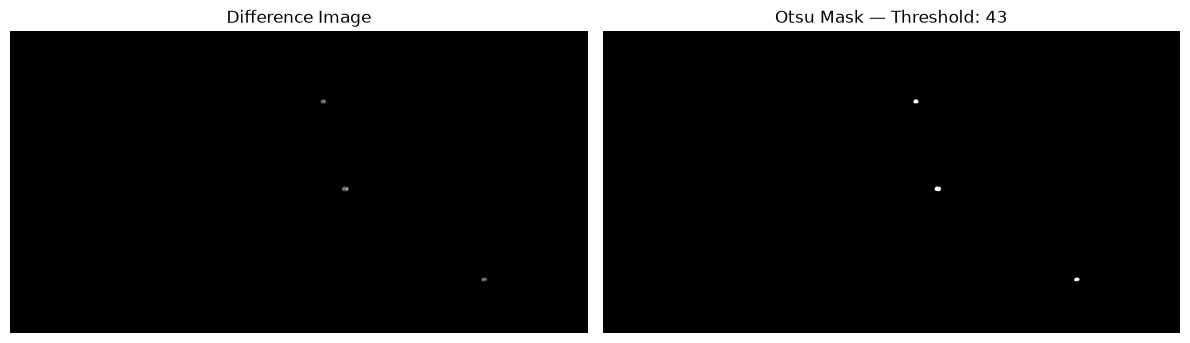

In [1]:
import sys
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from algorithms.common import load_image, preprocess_pair

DATASET_ROOT = PROJECT_ROOT / "data" / "raw" / "PCB_DATASET"

IMAGE_ROOT = DATASET_ROOT / "Images"
ANNOTATION_ROOT = DATASET_ROOT / "Annotations"
TEMPLATE_ROOT = DATASET_ROOT / "PCB_USED"

defective_path = (
    IMAGE_ROOT
    / "Missing_hole"
    / "01_missing_hole_01.jpg"
)

reference_path = TEMPLATE_ROOT / "01.JPG"

reference = load_image(reference_path)
defective = load_image(defective_path)

reference_gray, defective_gray, difference = preprocess_pair(
    reference,
    defective
)

start_time = time.perf_counter()

threshold_value, otsu_mask = cv2.threshold(
    difference,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

processing_time_ms = (
    time.perf_counter() - start_time
) * 1000

print("Otsu threshold:", threshold_value)
print(f"Processing time: {processing_time_ms:.3f} ms")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(difference, cmap="gray")
plt.title("Difference Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(otsu_mask, cmap="gray")
plt.title(f"Otsu Mask — Threshold: {threshold_value:.0f}")
plt.axis("off")

plt.tight_layout()
plt.show()